# <a id='toc1_'></a>[Global model fitting and results](#toc0_)

This notebook fits each global model per model type and calculates NRMSE and feature importance. It plots feature importance, too.



**Table of contents**<a id='toc0_'></a>    
- [Global model fitting and results](#toc1_)    
  - [Initial configuration](#toc1_1_)    
- [Preparing the data](#toc2_)    
- [Random Forest](#toc3_)    
  - [Fitting the model](#toc3_1_)    
  - [NRMSE](#toc3_2_)    
  - [Feature importance](#toc3_3_)    
- [XGB](#toc4_)    
  - [Fit model](#toc4_1_)    
  - [NRMSE](#toc4_2_)    
  - [Feature importance](#toc4_3_)    
- [HRF](#toc5_)    
  - [Fit models](#toc5_1_)    
  - [NRMSE](#toc5_2_)    
  - [Feature importance](#toc5_3_)    
- [HXGB](#toc6_)    
  - [Fit model](#toc6_1_)    
  - [NRMSE](#toc6_2_)    
  - [Feature importance](#toc6_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Initial configuration](#toc0_)

In [1]:
import pandas as pd
import sys
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append('../models')

from model_rr import Model

In [2]:
df = pd.read_csv('../data/clean/full_data.csv')

In [3]:
cantons = [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 201, -202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 301, 302, 303, 304, 305, 306, 307, 308, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 701, 702, 703, 704, 705, 706]

cantons = [str(x) for x in cantons]

# <a id='toc2_'></a>[Preparing the data](#toc0_)

In [4]:
instancia = Model(df, "full")
X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = instancia.partition()

# <a id='toc3_'></a>[Random Forest](#toc0_)

## <a id='toc3_1_'></a>[Fitting the model](#toc0_)

In [ ]:
elapsed_time_rf = instancia.rf_reg(X_combined, y_combined, X_test, y_test, test, pds, epsilon)

time_rf_df = pd.DataFrame({"canton": ["full"], "time": [elapsed_time_rf]})

time_rf_df.to_csv('../data/comp_time/rf_comp_time_full.csv')

## <a id='toc3_2_'></a>[NRMSE](#toc0_)

In [5]:
canton_rf, point_rf, lower_bound_rf, upper_bound_rf = instancia.confint_nrmse("rf", X_combined, y_combined, X_test, y_test, epsilon, "test", n_bootstraps = 500)

print(f"Confint on test set. Mean: {point_rf}. Lower bound: {lower_bound_rf}. Upper bound: {upper_bound_rf}")

Elapsed time: 17.27 seconds
Confint on test set. Mean: 1.6694418860049618. Lower bound: 1.5500470567782516. Upper bound: 1.8084578149494086


## <a id='toc3_3_'></a>[Feature importance](#toc0_)

              Feature    imp_rf    std_rf
0            rr_lag_1  0.213181  0.010962
1            rr_lag_2  0.117788  0.009123
2            rr_lag_4  0.027804  0.005567
3            rr_lag_3  0.021627  0.004636
4    precip_max_lag_3  0.001094  0.000568
..                ...       ...       ...
103   tmax_mean_lag_4 -0.002329  0.000539
104   tmax_mean_lag_1 -0.002760  0.000660
105   temp_prom_lag_1 -0.002804  0.000546
106   tmin_mean_lag_4 -0.003458  0.000739
107   temp_prom_lag_3 -0.005056  0.000628

[108 rows x 3 columns]


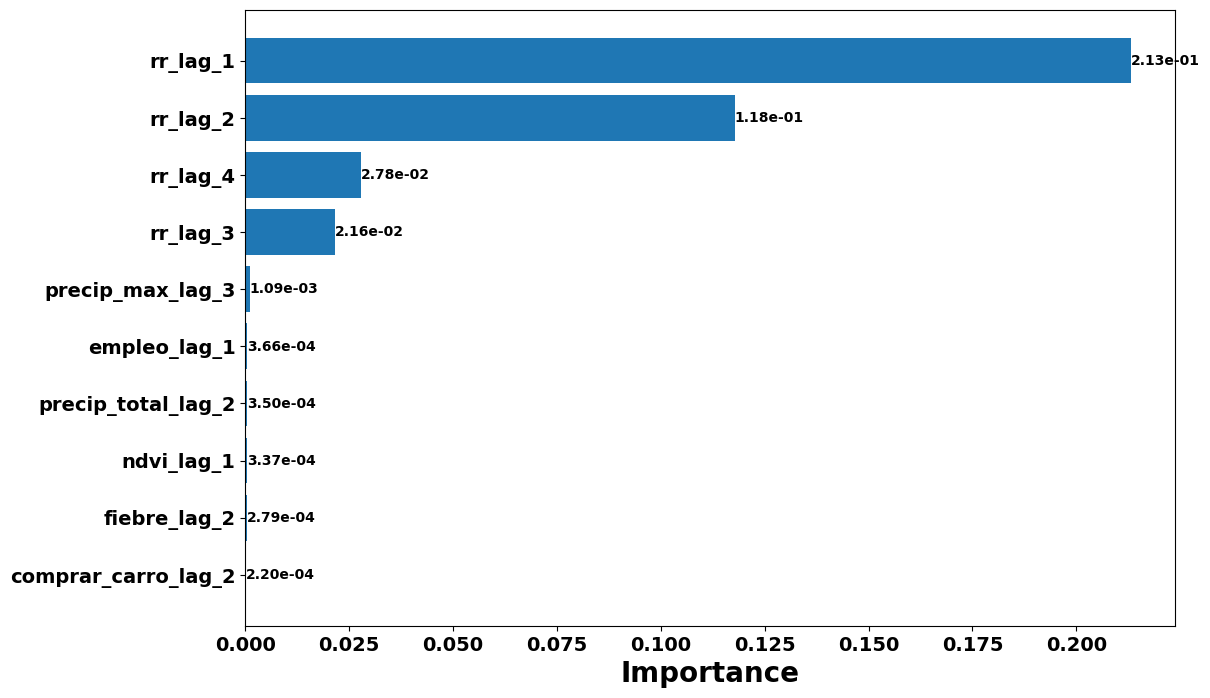

Elapsed time: 150.90 seconds


,Feature,imp_rf,std_rf
0,rr_lag_1,0.213181,0.010962
1,rr_lag_2,0.117788,0.009123
2,rr_lag_4,0.027804,0.005567
3,rr_lag_3,0.021627,0.004636
4,precip_max_lag_3,0.001094,0.000568
...,...,...,...
103,tmax_mean_lag_4,-0.002329,0.000539
104,tmax_mean_lag_1,-0.002760,0.000660
105,temp_prom_lag_1,-0.002804,0.000546
106,tmin_mean_lag_4,-0.003458,0.000739


In [ ]:
instancia.var_importance(X_test, y_test, "rf", repeats = 100)

# <a id='toc4_'></a>[XGB](#toc0_)

## <a id='toc4_1_'></a>[Fit model](#toc0_)

In [ ]:
elapsed_time_xgb = instancia.xgb_reg(X_combined, y_combined, X_test, y_test, test, pds, epsilon)

time_xgb_df = pd.DataFrame({"canton": ["full"], "time": [elapsed_time_xgb]})

time_xgb_df.to_csv('../data/comp_time/xgb_comp_time_full.csv')

## <a id='toc4_2_'></a>[NRMSE](#toc0_)

In [7]:
canton_xgb, point_xgb, lower_bound_xgb, upper_bound_xgb = instancia.confint_nrmse("xgb", X_combined, y_combined, X_test, y_test, epsilon, "test", n_bootstraps = 500)

print(f"Confint on test set. Mean: {point_xgb}. Lower bound: {lower_bound_xgb}. Upper bound: {upper_bound_xgb}")

Elapsed time: 4.31 seconds
Confint on test set. Mean: 1.6618060867030182. Lower bound: 1.5377395389439532. Upper bound: 1.8031375286391356


## <a id='toc4_3_'></a>[Feature importance](#toc0_)

                 Feature   imp_xgb   std_xgb
0               rr_lag_1  0.228715  0.011006
1               rr_lag_2  0.086396  0.007653
2               rr_lag_4  0.030009  0.004987
3               rr_lag_3  0.026500  0.004629
4     precip_total_lag_2  0.000645  0.000365
..                   ...       ...       ...
103     precip_max_lag_4 -0.000225  0.000175
104      temp_prom_lag_1 -0.000228  0.000125
105      tmin_mean_lag_1 -0.000259  0.000189
106  precip_median_lag_3 -0.000265  0.000173
107      tmax_mean_lag_3 -0.000575  0.000578

[108 rows x 3 columns]


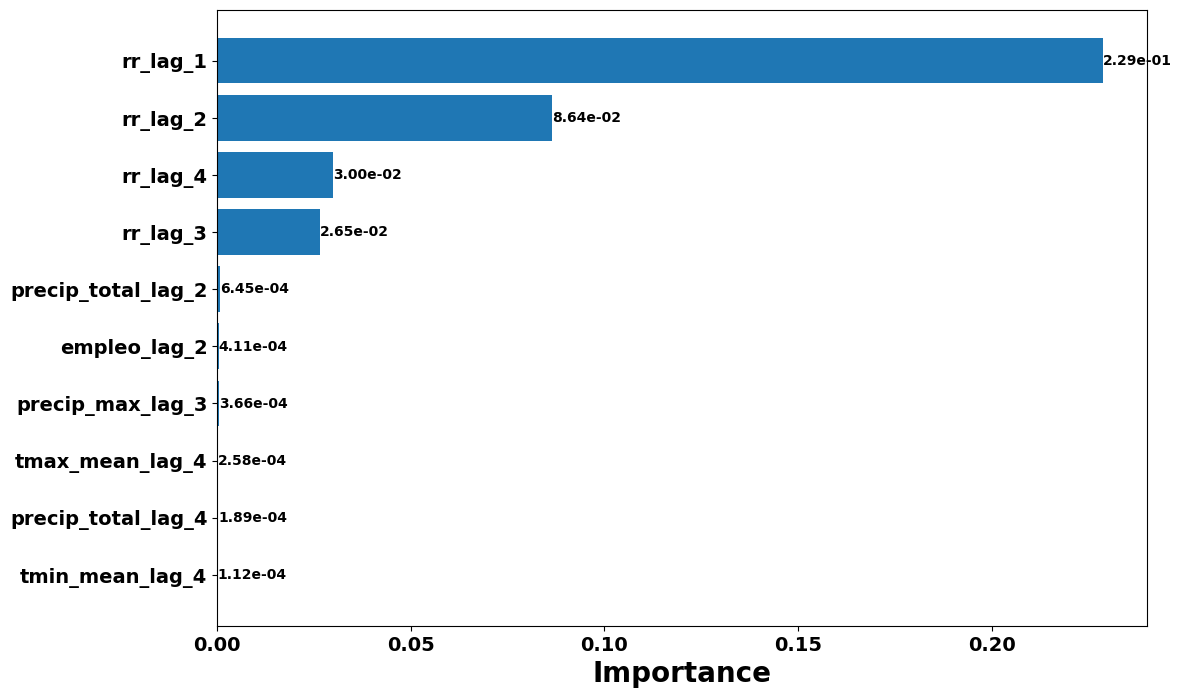

Elapsed time: 68.47 seconds


,Feature,imp_xgb,std_xgb
0,rr_lag_1,0.228715,0.011006
1,rr_lag_2,0.086396,0.007653
2,rr_lag_4,0.030009,0.004987
3,rr_lag_3,0.026500,0.004629
4,precip_total_lag_2,0.000645,0.000365
...,...,...,...
103,precip_max_lag_4,-0.000225,0.000175
104,temp_prom_lag_1,-0.000228,0.000125
105,tmin_mean_lag_1,-0.000259,0.000189
106,precip_median_lag_3,-0.000265,0.000173


In [ ]:
instancia.var_importance(X_test, y_test, "xgb", repeats = 100)

# <a id='toc5_'></a>[HRF](#toc0_)

## <a id='toc5_1_'></a>[Fit models](#toc0_)

In [ ]:
best_th_hrf, elapsed_time_hrf = instancia.hybrid("hrf", X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon)

time_hrf_df = pd.DataFrame({"canton": ["full"], "time": [elapsed_time_hrf]})

time_hrf_df.to_csv('../data/comp_time/hrf_comp_time_full.csv')

## <a id='toc5_2_'></a>[NRMSE](#toc0_)

In [9]:
canton_hrf, point_hrf, lower_bound_hrf, upper_bound_hrf = instancia.confint_nrmse("hrf", X_combined, y_combined, X_test, y_test, epsilon, "test", n_bootstraps = 500)

print(f"Confint on test set. Mean: {point_hrf}. Lower bound: {lower_bound_hrf}. Upper bound: {upper_bound_hrf}")

Elapsed time: 27.86 seconds
Confint on test set. Mean: 1.691772081262523. Lower bound: 1.5784382034656876. Upper bound: 1.7868586904498158


## <a id='toc5_3_'></a>[Feature importance](#toc0_)

Classifier


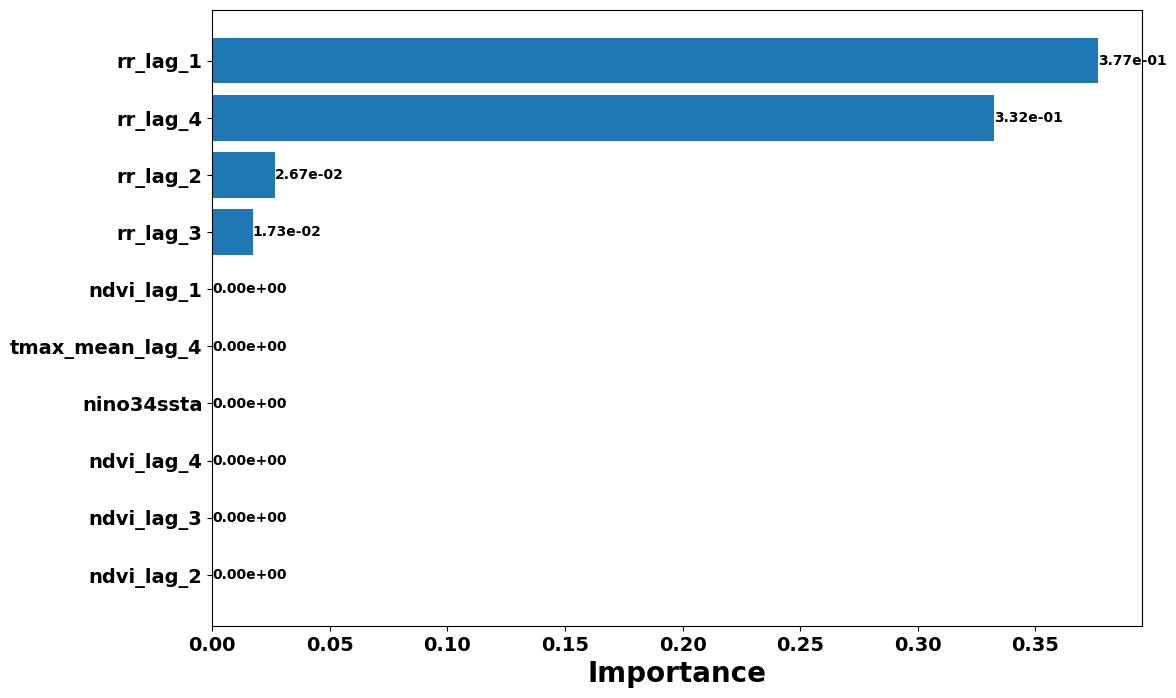

Regressor
                 Feature   imp_hrf   std_hrf
0               rr_lag_1  0.367504  0.015805
1               rr_lag_2  0.274323  0.015082
2               rr_lag_4  0.068480  0.005018
3               rr_lag_3  0.061911  0.003432
4        tmax_mean_lag_1  0.018094  0.001669
..                   ...       ...       ...
103     nino34ssta_lag_2 -0.008473  0.002404
104    precip_mean_lag_1 -0.010462  0.001524
105     nino34ssta_lag_4 -0.012515  0.004241
106     nino34ssta_lag_3 -0.012908  0.002699
107  precip_median_lag_2 -0.013116  0.002711

[108 rows x 3 columns]


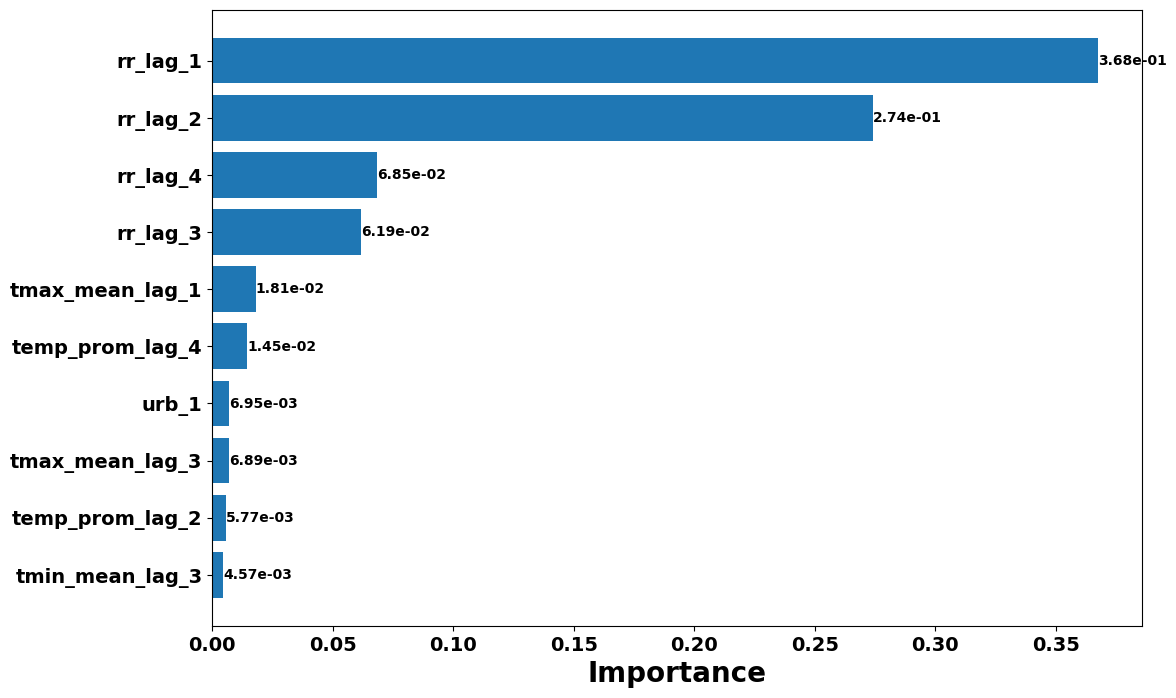

Elapsed time: 234.22 seconds


,Feature,imp_hrf,std_hrf
0,rr_lag_1,0.367504,0.015805
1,rr_lag_2,0.274323,0.015082
2,rr_lag_4,0.068480,0.005018
3,rr_lag_3,0.061911,0.003432
4,tmax_mean_lag_1,0.018094,0.001669
...,...,...,...
103,nino34ssta_lag_2,-0.008473,0.002404
104,precip_mean_lag_1,-0.010462,0.001524
105,nino34ssta_lag_4,-0.012515,0.004241
106,nino34ssta_lag_3,-0.012908,0.002699


In [ ]:
instancia.var_importance(X_test, y_test, "hrf", repeats = 100)

# <a id='toc6_'></a>[HXGB](#toc0_)

## <a id='toc6_1_'></a>[Fit model](#toc0_)

In [ ]:
best_th_hxgb, elapsed_time_hxgb = instancia.hybrid("hxgb", X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon)

time_hxgb_df = pd.DataFrame({"canton": ["full"], "time": [elapsed_time_hxgb]})

time_hxgb_df.to_csv('../data/model_results/comp_time/hxgb_comp_time_full.csv')

## <a id='toc6_2_'></a>[NRMSE](#toc0_)

In [13]:
canton_hxgb, point_hxgb, lower_bound_hxgb, upper_bound_hxgb = instancia.confint_nrmse("hxgb", X_combined, y_combined, X_test, y_test, epsilon, "test", n_bootstraps = 500)

print(f"Confint on test set. Mean: {point_hxgb}. Lower bound: {lower_bound_hxgb}. Upper bound: {upper_bound_hxgb}")

Elapsed time: 35.29 seconds
Confint on test set. Mean: 1.7197191810659755. Lower bound: 1.610088004412914. Upper bound: 1.8254401330533836


## <a id='toc6_3_'></a>[Feature importance](#toc0_)

Classifier


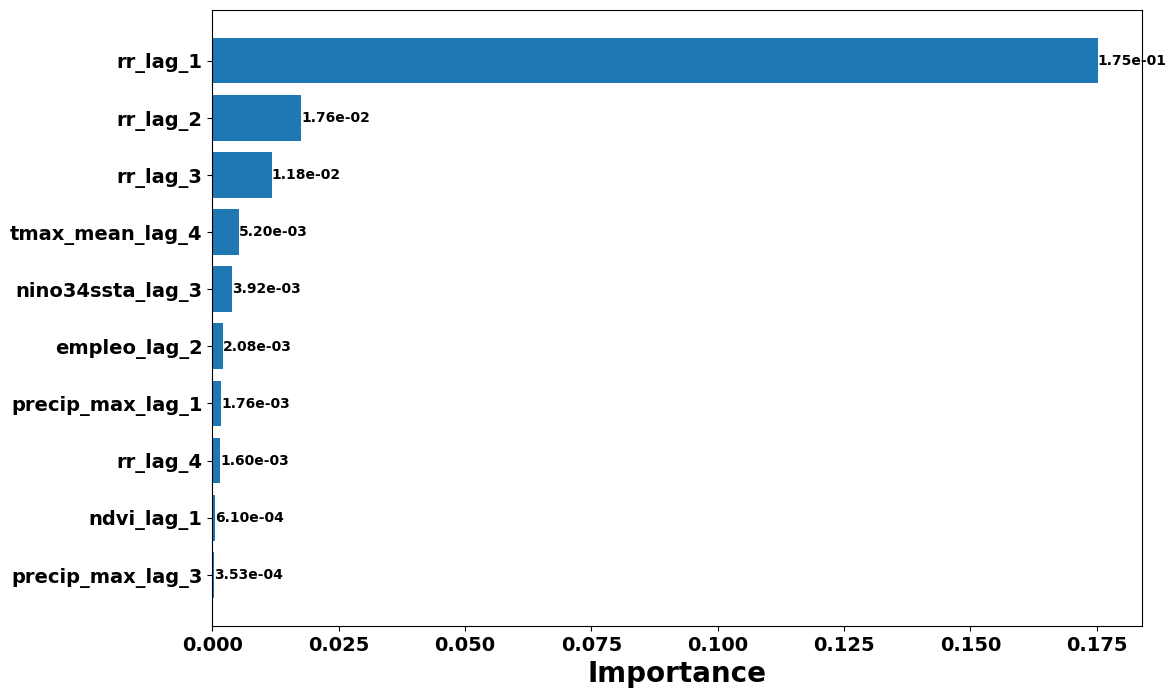

Regressor
                 Feature  imp_hxgb  std_hxgb
0               rr_lag_1  0.236139  0.012905
1               rr_lag_2  0.136582  0.012338
2               rr_lag_3  0.073037  0.007415
3               rr_lag_4  0.049293  0.007357
4                  urb_1  0.031541  0.005824
..                   ...       ...       ...
103  precip_median_lag_3 -0.010542  0.003127
104      tmax_mean_lag_2 -0.011273  0.000696
105  precip_median_lag_1 -0.015414  0.001614
106  precip_median_lag_2 -0.015674  0.003160
107   precip_total_lag_1 -0.015980  0.003153

[108 rows x 3 columns]


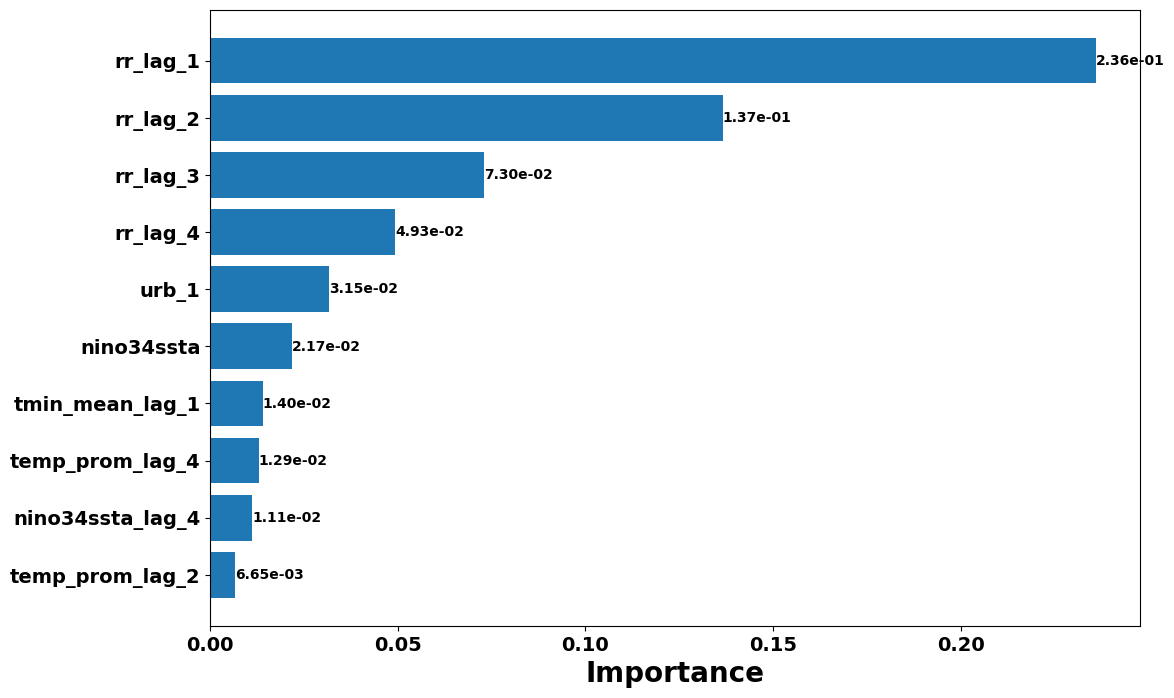

Elapsed time: 166.56 seconds


,Feature,imp_hxgb,std_hxgb
0,rr_lag_1,0.236139,0.012905
1,rr_lag_2,0.136582,0.012338
2,rr_lag_3,0.073037,0.007415
3,rr_lag_4,0.049293,0.007357
4,urb_1,0.031541,0.005824
...,...,...,...
103,precip_median_lag_3,-0.010542,0.003127
104,tmax_mean_lag_2,-0.011273,0.000696
105,precip_median_lag_1,-0.015414,0.001614
106,precip_median_lag_2,-0.015674,0.003160


In [ ]:
instancia.var_importance(X_test, y_test, "hxgb", repeats = 100)